# Rescue Drone Reinforcement Learning Environment

**Custom Gymnasium Environment + Value Iteration Planner**

### State Space
- **Position**: 6×6 grid
- **Battery Level**: 0–10 units (start: 4)
- **Rescue Status**: 3 binary flags (rescued / not rescued)

### Action Space
| Action | Description |
|--------|-------------|
| 0 | Move Up |
| 1 | Move Down |
| 2 | Move Left |
| 3 | Move Right |
| 4 | Hover |

### Grid Layout
| Symbol | Cell Type |
|--------|-----------|
| S | Start Position (0,0) |
| C | Charging Station — full recharge on entry; +2 on hover |
| X | Danger Zone — heavy penalty |
| W | Wind Zone — 30% stochastic direction change |
| B | Blocked Cell — impassable |
| R | Rescue Target |

### Reward System
| Event | Reward |
|-------|--------|
| Rescue target reached | +20 |
| Charging station entered | +5 |
| Danger zone entered | −10 |
| Regular movement | −1 |
| Battery exhausted | −20 |

## Cell 1 — Imports

In [22]:
import gymnasium as gym
from gymnasium import spaces

import numpy as np
import random
import time
from io import BytesIO
from PIL import Image, ImageDraw, ImageFont
from collections import namedtuple
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
import matplotlib.patches as patches

print('Imports OK')

Imports OK


## Cell 2 — Action & Status Definitions

In [23]:
ACTION_SELECTION = namedtuple('ActionSelection',
                              ['MOVE_UP', 'MOVE_DOWN', 'MOVE_LEFT', 'MOVE_RIGHT', 'HOVER'])
RESCUE_STATUS = namedtuple('RescueStatus', ['NOT_RESCUED', 'RESCUED'])

a_sel    = ACTION_SELECTION(0, 1, 2, 3, 4)
r_status = RESCUE_STATUS(0, 1)

print('Action codes:', a_sel)
print('Rescue codes:', r_status)

Action codes: ActionSelection(MOVE_UP=0, MOVE_DOWN=1, MOVE_LEFT=2, MOVE_RIGHT=3, HOVER=4)
Rescue codes: RescueStatus(NOT_RESCUED=0, RESCUED=1)


## Cell 3 — Custom Rescue Drone Environment

In [24]:
class RescueDroneEnv(gym.Env):
    """
    Custom Gymnasium environment for the Rescue Drone problem.
    No pygame — rendering is PIL-based for notebook compatibility.
    """

    metadata = {'render_modes': ['human'], 'render_fps': 5}

    def __init__(self, render_mode=None):
        super().__init__()

        # ── Configuration ──────────────────────────────────────
        self.grid_rows     = 6
        self.grid_cols     = 6
        self.max_steps     = 75
        self.MAX_BATTERY   = 10
        self.START_BATTERY = 4
        self.render_mode   = render_mode

        # ── Grid Layout ────────────────────────────────────────
        self.start_position    = (0, 0)
        self.charging_stations = [(0, 1), (4, 0)]
        self.danger_zones      = [(1, 1), (2, 4), (4, 2), (5, 5)]
        self.wind_zones        = [(0, 3), (3, 3)]
        self.blocked_cells     = [(2, 2), (3, 1), (4, 4)]
        self.targets           = [(2, 0), (2, 1), (5, 2)]

        # ── Spaces ─────────────────────────────────────────────
        self.action_space = spaces.Discrete(5)
        self.observation_space = spaces.Dict({
            'position': spaces.MultiDiscrete([self.grid_rows, self.grid_cols]),
            'battery':  spaces.Discrete(self.MAX_BATTERY + 1),
            'rescued':  spaces.MultiBinary(3)
        })

        # ── Runtime State ──────────────────────────────────────
        self.position        = list(self.start_position)
        self.battery_level   = self.START_BATTERY
        self.rescued_targets = [r_status.NOT_RESCUED] * 3
        self.step_count      = 0
        self.render_frames   = []
        self.cell_pixel_size = 100

    # ── Observation ────────────────────────────────────────────
    def get_observation(self):
        return {
            'position': np.array(self.position, dtype=np.int32),
            'battery':  self.battery_level,
            'rescued':  np.array(self.rescued_targets, dtype=np.int8)
        }

    # ── Cell-type helpers ──────────────────────────────────────
    def is_charging_station(self, p): return p in self.charging_stations
    def is_danger_zone(self, p):      return p in self.danger_zones
    def is_wind_zone(self, p):        return p in self.wind_zones
    def is_blocked_cell(self, p):     return p in self.blocked_cells
    def is_target(self, p):           return p in self.targets

    def recharge_battery(self):
        self.battery_level = self.MAX_BATTERY

    def update_rescue_status(self):
        pos = tuple(self.position)
        for idx, target in enumerate(self.targets):
            if pos == target and self.rescued_targets[idx] == r_status.NOT_RESCUED:
                self.rescued_targets[idx] = r_status.RESCUED

    def all_targets_rescued(self):
        return all(s == r_status.RESCUED for s in self.rescued_targets)

    # ── Wind Disturbance ───────────────────────────────────────
    def apply_wind_disturbance(self, action):
        if not self.is_wind_zone(tuple(self.position)):
            return action
        if action == a_sel.HOVER:
            return action
        if np.random.random() < 0.30:
            action = random.choice([a_sel.MOVE_UP, a_sel.MOVE_DOWN,
                                    a_sel.MOVE_LEFT, a_sel.MOVE_RIGHT])
        return action

    # ── Next Position ──────────────────────────────────────────
    def get_next_position(self, action):
        row, col = self.position
        if   action == a_sel.MOVE_UP:    row -= 1
        elif action == a_sel.MOVE_DOWN:  row += 1
        elif action == a_sel.MOVE_LEFT:  col -= 1
        elif action == a_sel.MOVE_RIGHT: col += 1
        row = max(0, min(row, self.grid_rows - 1))
        col = max(0, min(col, self.grid_cols - 1))
        return (row, col)

    # ── Reset ──────────────────────────────────────────────────
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.position        = list(self.start_position)
        self.battery_level   = self.START_BATTERY
        self.rescued_targets = [r_status.NOT_RESCUED] * 3
        self.step_count      = 0
        self.render_frames   = []
        self.render_frames.append(self.render_to_frame())
        return self.get_observation(), {}

    # ── Reward ─────────────────────────────────────────────────
    def get_reward(self, previous_rescue_status):
        reward = -1
        pos    = tuple(self.position)
        for idx in range(len(self.rescued_targets)):
            if (previous_rescue_status[idx] == r_status.NOT_RESCUED and
                    self.rescued_targets[idx] == r_status.RESCUED):
                return 20
        if self.is_charging_station(pos): reward = 5
        if self.is_danger_zone(pos):      reward = -10
        return reward

    # ── Termination ────────────────────────────────────────────
    def check_termination(self):
        return self.battery_level <= 0 or self.all_targets_rescued()

    # ── Step ───────────────────────────────────────────────────
    def step(self, action):
        self.step_count += 1
        prev_rescue = self.rescued_targets.copy()

        action = self.apply_wind_disturbance(action)
        self.battery_level -= 1

        candidate = self.get_next_position(action)
        if not self.is_blocked_cell(candidate):
            self.position = list(candidate)

        # Charging logic
        cur = tuple(self.position)
        if action == a_sel.HOVER and self.is_charging_station(cur):
            self.battery_level = min(self.MAX_BATTERY, self.battery_level + 2)
        elif self.is_charging_station(cur):
            self.recharge_battery()

        self.update_rescue_status()
        reward = self.get_reward(prev_rescue)
        if self.battery_level <= 0:
            reward += -20

        terminated = self.check_termination()
        truncated  = self.step_count >= self.max_steps
        obs        = self.get_observation()
        info       = {'battery': self.battery_level,
                      'step_count': self.step_count,
                      'rescued_targets': self.rescued_targets}

        self.render_frames.append(self.render_to_frame())
        return obs, reward, terminated, truncated, info

    # ── Font Helper ────────────────────────────────────────────
    def _get_font(self, size):
        for fp in [
            '/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf',
            '/usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf',
            '/usr/share/fonts/truetype/freefont/FreeSansBold.ttf',
        ]:
            try:
                return ImageFont.truetype(fp, size)
            except Exception:
                continue
        return ImageFont.load_default()

    # ── PIL Rendering ──────────────────────────────────────────
    def render_to_frame(self):
        cs      = self.cell_pixel_size
        grid_px = self.grid_rows * cs
        sb_h    = 40   # status bar height

        color_map = {
            'free':             (220, 220, 220),
            'start':            (180, 180, 180),
            'charging':         (  0, 200,   0),
            'danger':           (220,   0,   0),
            'wind':             (255, 255,   0),
            'blocked':          (  0,   0,   0),
            'target_unrescued': (  0, 100, 255),
            'target_rescued':   (220, 220, 220),
        }
        label_color = {
            'charging':         (255, 255, 255),
            'danger':           (255, 255, 255),
            'wind':             (  0,   0,   0),
            'blocked':          (255, 255, 255),
            'target_unrescued': (255, 255, 255),
            'target_rescued':   (  0,   0,   0),
            'start':            (  0,   0,   0),
            'free':             (  0,   0,   0),
        }

        img  = Image.new('RGB', (grid_px, grid_px + sb_h), (245, 245, 220))
        draw = ImageDraw.Draw(img)
        lf   = self._get_font(28)   # label font
        df   = self._get_font(40)   # drone font
        sf   = self._get_font(18)   # status font

        # Draw cell backgrounds
        for row in range(self.grid_rows):
            for col in range(self.grid_cols):
                x0, y0 = col * cs, row * cs
                pos = (row, col)
                if   pos in self.charging_stations: ct = 'charging'
                elif pos in self.danger_zones:      ct = 'danger'
                elif pos in self.wind_zones:        ct = 'wind'
                elif pos in self.blocked_cells:     ct = 'blocked'
                elif pos in self.targets:
                    idx = self.targets.index(pos)
                    ct  = 'target_unrescued' if self.rescued_targets[idx] == r_status.NOT_RESCUED else 'target_rescued'
                elif pos == self.start_position:    ct = 'start'
                else:                               ct = 'free'
                draw.rectangle([x0, y0, x0 + cs, y0 + cs], fill=color_map[ct])

        # Grid lines
        for i in range(self.grid_rows + 1):
            draw.line([(0, i * cs), (grid_px, i * cs)], fill=(50, 50, 50), width=2)
        for j in range(self.grid_cols + 1):
            draw.line([(j * cs, 0), (j * cs, grid_px)], fill=(50, 50, 50), width=2)

        # Cell labels
        cell_labels = {}
        for p in self.charging_stations: cell_labels[p] = ('C', 'charging')
        for p in self.danger_zones:      cell_labels[p] = ('X', 'danger')
        for p in self.wind_zones:        cell_labels[p] = ('W', 'wind')
        for p in self.blocked_cells:     cell_labels[p] = ('B', 'blocked')
        for idx, p in enumerate(self.targets):
            ct = 'target_unrescued' if self.rescued_targets[idx] == r_status.NOT_RESCUED else 'target_rescued'
            cell_labels[p] = ('R', ct)
        if self.start_position not in cell_labels:
            cell_labels[self.start_position] = ('S', 'start')

        for (row, col), (lbl, ct) in cell_labels.items():
            cx = col * cs + cs // 2
            cy = row * cs + cs // 2
            draw.text((cx, cy), lbl, fill=label_color[ct], anchor='mm', font=lf)

        # Drone — large bold black D
        dr, dc = self.position
        draw.text((dc * cs + cs // 2, dr * cs + cs // 2),
                  'D', fill=(0, 0, 0), anchor='mm', font=df)

        # Status bar
        txt = (f'Battery: {self.battery_level}  |  '
               f'Step: {self.step_count}  |  '
               f'Rescued: {sum(self.rescued_targets)}/3')
        draw.text((grid_px // 2, grid_px + sb_h // 2),
                  txt, fill=(0, 0, 0), anchor='mm', font=sf)

        return np.array(img)

    # ── ipywidget Playback ─────────────────────────────────────
    def playback_rendering(self):
        if not self.render_frames:
            print('No frames captured. Run an episode first.')
            return

        image_widget = widgets.Image(format='png')
        slider = widgets.IntSlider(
            value=0, min=0, max=len(self.render_frames) - 1,
            step=1, description='Frame:',
            layout=widgets.Layout(width='620px')
        )
        label = widgets.Label(f'Total frames: {len(self.render_frames)}')

        def update(change):
            frame = self.render_frames[slider.value]
            buf   = BytesIO()
            Image.fromarray(frame).save(buf, format='PNG')
            image_widget.value = buf.getvalue()

        slider.observe(update, names='value')
        update(None)
        display(widgets.VBox([label, slider, image_widget]))

print('RescueDroneEnv class defined.')

RescueDroneEnv class defined.


## Cell 4 — Value Iteration Planner

In [25]:
class RescueDroneValueIteration:
    """
    Value Iteration Planner.

    State: (row, col, battery, rescue_0, rescue_1, rescue_2)
    """

    def __init__(self, env):
        self.env    = env.unwrapped if hasattr(env, 'unwrapped') else env
        self.gamma  = 0.95
        self.theta  = 1e-3
        self.states = []
        self.V      = {}
        self.policy = {}
        self.enumerate_states()

    # ── State Enumeration ──────────────────────────────────────
    def enumerate_states(self):
        self.states = []
        for row in range(self.env.grid_rows):
            for col in range(self.env.grid_cols):
                if (row, col) in self.env.blocked_cells:
                    continue
                for battery in range(self.env.MAX_BATTERY + 1):
                    for mask in range(8):
                        rs = ((mask >> 0) & 1, (mask >> 1) & 1, (mask >> 2) & 1)
                        state = (row, col, battery, *rs)
                        self.states.append(state)
                        self.V[state] = 0.0
        print(f'States enumerated: {len(self.states)}')

    # ── Terminal Check ─────────────────────────────────────────
    def is_terminal_state(self, state):
        return state[2] <= 0 or all(r == 1 for r in state[3:])

    # ── Valid Actions ──────────────────────────────────────────
    def get_valid_actions(self, state):
        row, col = state[0], state[1]
        valid = [a_sel.HOVER]
        if row > 0:                          valid.append(a_sel.MOVE_UP)
        if row < self.env.grid_rows - 1:     valid.append(a_sel.MOVE_DOWN)
        if col > 0:                          valid.append(a_sel.MOVE_LEFT)
        if col < self.env.grid_cols - 1:     valid.append(a_sel.MOVE_RIGHT)
        return valid

    # ── Movement ───────────────────────────────────────────────
    def move_state(self, state, action):
        row, col = state[0], state[1]
        deltas = {
            a_sel.MOVE_UP:    (-1,  0),
            a_sel.MOVE_DOWN:  ( 1,  0),
            a_sel.MOVE_LEFT:  ( 0, -1),
            a_sel.MOVE_RIGHT: ( 0,  1),
            a_sel.HOVER:      ( 0,  0),
        }
        dr, dc = deltas[action]
        nr = max(0, min(row + dr, self.env.grid_rows - 1))
        nc = max(0, min(col + dc, self.env.grid_cols - 1))
        if (nr, nc) in self.env.blocked_cells:
            return (row, col)
        return (nr, nc)

    # ── State Transition ───────────────────────────────────────
    def get_next_state(self, state, action):
        row, col, battery, *rescued = state
        rescued = list(rescued)
        nr, nc  = self.move_state(state, action)
        battery = max(0, battery - 1)

        # Hover in charging station → +2 battery
        if action == a_sel.HOVER and (row, col) in self.env.charging_stations:
            battery = min(self.env.MAX_BATTERY, battery + 2)
        # Enter charging station via movement → full recharge
        elif (nr, nc) in self.env.charging_stations and action != a_sel.HOVER:
            battery = self.env.MAX_BATTERY

        for idx, target in enumerate(self.env.targets):
            if (nr, nc) == target:
                rescued[idx] = 1

        return (nr, nc, battery, *rescued)

    # ── Reward Model ───────────────────────────────────────────
    def get_transition_reward(self, current_state, next_state):
        reward   = -1
        next_pos = (next_state[0], next_state[1])
        for idx in range(3):
            if current_state[3 + idx] == 0 and next_state[3 + idx] == 1:
                return 20
        if next_pos in self.env.charging_stations: reward = 5
        if next_pos in self.env.danger_zones:      reward = -10
        if next_state[2] <= 0:                     reward -= 20
        return reward

    # ── Transition Model (wind stochasticity) ──────────────────
    def get_transition_model(self, state, action):
        pos         = (state[0], state[1])
        transitions = []

        if pos in self.env.wind_zones and action != a_sel.HOVER:
            for candidate in [a_sel.MOVE_UP, a_sel.MOVE_DOWN,
                               a_sel.MOVE_LEFT, a_sel.MOVE_RIGHT]:
                prob = 0.70 if candidate == action else 0.10
                ns   = self.get_next_state(state, candidate)
                r    = self.get_transition_reward(state, ns)
                transitions.append((prob, ns, r))
        else:
            ns = self.get_next_state(state, action)
            r  = self.get_transition_reward(state, ns)
            transitions.append((1.0, ns, r))

        return transitions

    # ── Q-Value ────────────────────────────────────────────────
    def compute_q_value(self, state, action):
        return sum(
            p * (r + self.gamma * self.V.get(ns, 0.0))
            for p, ns, r in self.get_transition_model(state, action)
        )

    # ── Bellman Backup ─────────────────────────────────────────
    def bellman_backup(self, state):
        if self.is_terminal_state(state):
            return 0.0
        return max(self.compute_q_value(state, a)
                   for a in self.get_valid_actions(state))

    # ── Asynchronous Value Iteration ───────────────────────────
    def run_value_iteration(self):
        print('Starting Value Iteration ...\n')
        start_time = time.time()
        iteration  = 0

        while True:
            delta     = 0.0
            iteration += 1
            for state in self.states:
                old_v          = self.V[state]
                new_v          = self.bellman_backup(state)
                self.V[state]  = new_v
                delta          = max(delta, abs(old_v - new_v))

            print(f'  Iteration {iteration:3d}  |  Delta: {delta:.6f}')

            if delta < self.theta:
                elapsed = time.time() - start_time
                print(f'\n✓ Converged after {iteration} iterations')
                print(f'  Final delta : {delta:.6f}')
                print(f'  Runtime     : {elapsed:.2f} seconds')
                break

        self.extract_policy()

    # ── Policy Extraction ──────────────────────────────────────
    def extract_policy(self):
        print('\nExtracting Optimal Policy ...')
        self.policy = {}
        for state in self.states:
            if self.is_terminal_state(state):
                continue
            self.policy[state] = max(
                self.get_valid_actions(state),
                key=lambda a: self.compute_q_value(state, a)
            )
        print('Policy Extraction Complete.')

    # ── Action Icon ────────────────────────────────────────────
    def get_action_icon(self, action):
        return {a_sel.MOVE_UP: '↑', a_sel.MOVE_DOWN: '↓',
                a_sel.MOVE_LEFT: '←', a_sel.MOVE_RIGHT: '→',
                a_sel.HOVER: '↺'}.get(action, '')

    # ── Policy Grid Visualisation (PIL + matplotlib) ───────────
    def render_policy_grid_old(self, battery_level=4, rescue_status=(0, 0, 0)):
        env = self.env
        cs  = 100
        gpx = env.grid_rows * cs

        color_map = {
            'free':             (220, 220, 220),
            'start':            (180, 180, 180),
            'charging':         (  0, 200,   0),
            'danger':           (220,   0,   0),
            'wind':             (255, 255,   0),
            'blocked':          (  0,   0,   0),
            'target_unrescued': (  0, 100, 255),
        }
        label_color = {
            'charging': (255,255,255), 'danger': (255,255,255),
            'wind': (0,0,0), 'blocked': (255,255,255),
            'target_unrescued': (255,255,255), 'start': (0,0,0), 'free': (0,0,0)
        }

        # Font
        lf = af = ImageFont.load_default()
        for fp in ['/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf',
                   '/usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf',
                   '/usr/share/fonts/truetype/freefont/FreeSansBold.ttf']:
            try:
                lf = ImageFont.truetype(fp, 22)
                af = ImageFont.truetype(fp, 34)
                break
            except Exception:
                continue

        img  = Image.new('RGB', (gpx, gpx), (245, 245, 220))
        draw = ImageDraw.Draw(img)

        # Cells
        for row in range(env.grid_rows):
            for col in range(env.grid_cols):
                pos = (row, col)
                if   pos in env.charging_stations: ct = 'charging'
                elif pos in env.danger_zones:      ct = 'danger'
                elif pos in env.wind_zones:        ct = 'wind'
                elif pos in env.blocked_cells:     ct = 'blocked'
                elif pos in env.targets:           ct = 'target_unrescued'
                elif pos == env.start_position:    ct = 'start'
                else:                              ct = 'free'
                draw.rectangle([col*cs, row*cs, col*cs+cs, row*cs+cs], fill=color_map[ct])

        # Grid lines
        for i in range(env.grid_rows + 1):
            draw.line([(0, i*cs), (gpx, i*cs)], fill=(50,50,50), width=2)
        for j in range(env.grid_cols + 1):
            draw.line([(j*cs, 0), (j*cs, gpx)], fill=(50,50,50), width=2)

        # Static cell labels (top portion of cell)
        slabels = {}
        for p in env.charging_stations: slabels[p] = ('C', 'charging')
        for p in env.danger_zones:      slabels[p] = ('X', 'danger')
        for p in env.wind_zones:        slabels[p] = ('W', 'wind')
        for p in env.blocked_cells:     slabels[p] = ('B', 'blocked')
        for p in env.targets:           slabels[p] = ('R', 'target_unrescued')
        if env.start_position not in slabels:
            slabels[env.start_position] = ('S', 'start')

        for (row, col), (lbl, ct) in slabels.items():
            draw.text((col*cs + cs//2, row*cs + cs//4),
                      lbl, fill=label_color.get(ct, (0,0,0)), anchor='mm', font=lf)

        # Policy arrows (bottom portion of cell)
        for row in range(env.grid_rows):
            for col in range(env.grid_cols):
                state = (row, col, battery_level, *rescue_status)
                if state not in self.policy:
                    continue
                icon = self.get_action_icon(self.policy[state])
                pos  = (row, col)
                ac   = (255,255,255) if pos in (env.blocked_cells + env.danger_zones +
                        env.charging_stations + env.targets) else (0, 0, 0)
                draw.text((col*cs + cs//2, row*cs + cs*3//4),
                          icon, fill=ac, anchor='mm', font=af)

        fig, ax = plt.subplots(figsize=(7, 7))
        ax.imshow(np.array(img))
        ax.axis('off')
        ax.set_title(f'Optimal Policy  —  Battery={battery_level}, Rescue={rescue_status}',
                     fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.show()

    def render_policy_grid(self, battery_level=4, rescue_status=(0, 0, 0)):
        env = self.env
        fig, ax = plt.subplots(figsize=(8, 8))

        color_map = {
            'free':             '#DCDCDC',
            'start':            '#B4B4B4',
            'charging':         '#00C800',
            'danger':           '#DC0000',
            'wind':             '#FFFF00',
            'blocked':          '#000000',
            'target_unrescued': '#0064FF',
        }
        cell_labels = {
            'charging': 'C', 'danger': 'X', 'wind': 'W',
            'blocked': 'B', 'target_unrescued': 'R', 'start': 'S'
        }
        label_colors = {
            'charging': 'white', 'danger': 'white', 'wind': 'black',
            'blocked': 'white', 'target_unrescued': 'white', 'start': 'black'
        }
        arrow_deltas = {
            a_sel.MOVE_UP:    ( 0,  0.25),
            a_sel.MOVE_DOWN:  ( 0, -0.25),
            a_sel.MOVE_LEFT:  (-0.25, 0),
            a_sel.MOVE_RIGHT: ( 0.25, 0),
            a_sel.HOVER:      None,
        }

        for row in range(env.grid_rows):
            for col in range(env.grid_cols):
                pos = (row, col)
                # Determine cell type
                if   pos in env.charging_stations: ct = 'charging'
                elif pos in env.danger_zones:      ct = 'danger'
                elif pos in env.wind_zones:        ct = 'wind'
                elif pos in env.blocked_cells:     ct = 'blocked'
                elif pos in env.targets:           ct = 'target_unrescued'
                elif pos == env.start_position:    ct = 'start'
                else:                              ct = 'free'

                # Draw cell
                rect = patches.Rectangle((col, env.grid_rows - 1 - row), 1, 1,
                                        linewidth=1.5, edgecolor='#323232',
                                        facecolor=color_map[ct])
                ax.add_patch(rect)

                # Cell label (top-left area)
                if ct in cell_labels:
                    ax.text(col + 0.18, env.grid_rows - 1 - row + 0.78,
                            cell_labels[ct],
                            color=label_colors[ct], fontsize=11,
                            fontweight='bold', ha='center', va='center')

                # Policy arrow
                if ct == 'blocked':
                    continue
                state = (row, col, battery_level, *rescue_status)
                if state not in self.policy:
                    continue

                action = self.policy[state]
                cx = col + 0.5
                cy = env.grid_rows - 1 - row + 0.5
                delta = arrow_deltas[action]

                if delta is None:
                    # Hover — draw a circle
                    circle = plt.Circle((cx, cy), 0.18, color='black', fill=False, linewidth=2)
                    ax.add_patch(circle)
                else:
                    dx, dy = delta
                    ax.annotate('', xy=(cx + dx, cy + dy), xytext=(cx - dx, cy - dy),
                                arrowprops=dict(arrowstyle='->', color='black', lw=2.0))

        ax.set_xlim(0, env.grid_cols)
        ax.set_ylim(0, env.grid_rows)
        ax.set_xticks(range(env.grid_cols))
        ax.set_yticks(range(env.grid_rows))
        ax.set_xticklabels(range(env.grid_cols))
        ax.set_yticklabels(range(env.grid_rows - 1, -1, -1))
        ax.set_title(f'Optimal Policy  —  Battery={battery_level}, Rescue={rescue_status}',
                    fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.show()
    # ── Value Heatmap ──────────────────────────────────────────
    def plot_value_heatmap(self, battery_level=4, rescue_status=(0, 0, 0)):
        env        = self.env
        value_grid = np.full((env.grid_rows, env.grid_cols), np.nan)
        for row in range(env.grid_rows):
            for col in range(env.grid_cols):
                if (row, col) in env.blocked_cells:
                    continue
                state = (row, col, battery_level, *rescue_status)
                if state in self.V:
                    value_grid[row][col] = self.V[state]

        fig, ax = plt.subplots(figsize=(7, 6))
        hm = ax.imshow(value_grid, cmap='viridis', interpolation='nearest')
        plt.colorbar(hm, ax=ax, label='V*(s)')

        labels = {}
        for p in env.charging_stations: labels[p] = 'C'
        for p in env.danger_zones:      labels[p] = 'X'
        for p in env.wind_zones:        labels[p] = 'W'
        for p in env.blocked_cells:     labels[p] = 'B'
        for p in env.targets:           labels[p] = 'R'

        for (r, c), lbl in labels.items():
            ax.text(c, r, lbl, ha='center', va='center',
                    color='white', fontsize=13, fontweight='bold')

        ax.set_title(f'State Value Heatmap\nBattery={battery_level}, Rescue={rescue_status}',
                     fontsize=13)
        ax.set_xlabel('Column')
        ax.set_ylabel('Row')
        ax.set_xticks(range(env.grid_cols))
        ax.set_yticks(range(env.grid_rows))
        plt.tight_layout()
        plt.show()

    # ── Simulate Optimal Rescue ────────────────────────────────
    def simulate_optimal_rescue(self):
        env = self.env
        env.reset()
        total_reward = 0
        print('\nExecuting Optimal Policy\n')

        while True:
            state = (env.position[0], env.position[1], env.battery_level,
                     env.rescued_targets[0], env.rescued_targets[1], env.rescued_targets[2])
            action = self.policy.get(state, a_sel.HOVER)
            _, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward
            print(f'  Pos={tuple(env.position)}  Battery={env.battery_level}  '
                  f'Action={self.get_action_icon(action)}  Reward={reward}  Total={total_reward}')
            if terminated or truncated:
                break

        print(f'\nMission Complete — Total Reward: {total_reward}')
        env.playback_rendering()

print('RescueDroneValueIteration class defined.')

RescueDroneValueIteration class defined.


## Cell 5 — Environment Registration & Smoke Test
Quick sanity check that reset, step, and rendering all work.

Start position : (0, 0)
Battery        : 4
Rescued        : [0, 0, 0]


c:\Users\rahul\AppData\Local\Programs\Python\Python313\Lib\site-packages\gymnasium\envs\registration.py:637: UserWarning: WARN: Overriding environment RescueDrone-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")


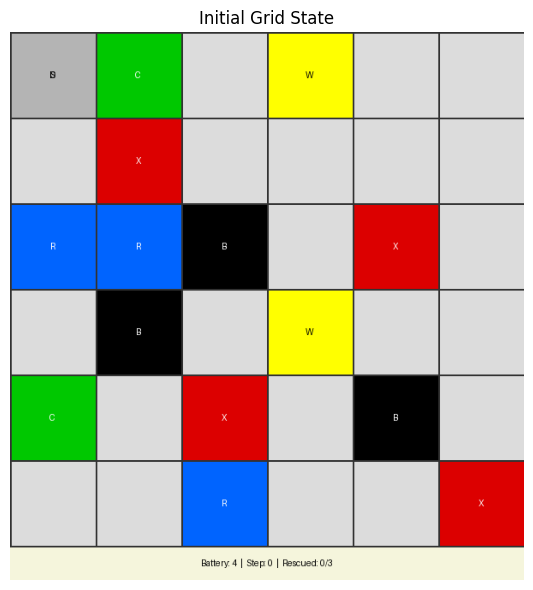

Smoke test PASSED


In [26]:
try:
    from gymnasium.envs.registration import register
    register(id='RescueDrone-v0',
             entry_point='__main__:RescueDroneEnv',
             max_episode_steps=75)
except Exception:
    pass

env = RescueDroneEnv()
obs, info = env.reset()
print(f'Start position : {tuple(env.position)}')
print(f'Battery        : {env.battery_level}')
print(f'Rescued        : {env.rescued_targets}')

# Show initial frame
frame = env.render_to_frame()
plt.figure(figsize=(6, 6))
plt.imshow(frame)
plt.axis('off')
plt.title('Initial Grid State')
plt.tight_layout()
plt.show()
print('Smoke test PASSED')

## Cell 6 — Random Agent Episode
Run one episode with a random policy and use the ipywidget slider to replay it.

In [27]:
env = RescueDroneEnv()
obs, info = env.reset()

episode_over  = False
total_reward  = 0

while not episode_over:
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    total_reward += reward
    episode_over  = terminated or truncated

print(f'Episode finished — Steps: {env.step_count}  Total Reward: {total_reward}')
print(f'Rescued: {sum(env.rescued_targets)}/3')
print(f'Frames captured: {len(env.render_frames)}')

# Interactive playback
env.playback_rendering()

Episode finished — Steps: 4  Total Reward: -24
Rescued: 0/3
Frames captured: 5


## Cell 7 — Value Iteration
Enumerate all states, run asynchronous Bellman updates until convergence (δ < 10⁻³), then extract the optimal policy.

In [28]:
env     = RescueDroneEnv()
env.reset()
planner = RescueDroneValueIteration(env)
planner.run_value_iteration()

States enumerated: 2904
Starting Value Iteration ...

  Iteration   1  |  Delta: 51.797325
  Iteration   2  |  Delta: 34.507232
  Iteration   3  |  Delta: 20.185125
  Iteration   4  |  Delta: 18.004875
  Iteration   5  |  Delta: 12.787825
  Iteration   6  |  Delta: 5.700000
  Iteration   7  |  Delta: 5.017147
  Iteration   8  |  Delta: 4.766289
  Iteration   9  |  Delta: 4.527975
  Iteration  10  |  Delta: 3.151247
  Iteration  11  |  Delta: 2.993685
  Iteration  12  |  Delta: 2.844000
  Iteration  13  |  Delta: 2.701800
  Iteration  14  |  Delta: 2.566710
  Iteration  15  |  Delta: 2.438375
  Iteration  16  |  Delta: 2.316456
  Iteration  17  |  Delta: 2.200633
  Iteration  18  |  Delta: 2.090602
  Iteration  19  |  Delta: 1.986072
  Iteration  20  |  Delta: 1.886768
  Iteration  21  |  Delta: 1.792430
  Iteration  22  |  Delta: 1.702808
  Iteration  23  |  Delta: 1.617668
  Iteration  24  |  Delta: 1.536784
  Iteration  25  |  Delta: 1.459945
  Iteration  26  |  Delta: 1.386948
  Ite

## Cell 8 — Policy Visualisation
The grid below shows the optimal action at each cell for a given battery level and rescue status.
- **Top of each cell**: cell-type label (C, X, W, B, R, S)
- **Bottom of each cell**: optimal action arrow (↑ ↓ ← → ↺)

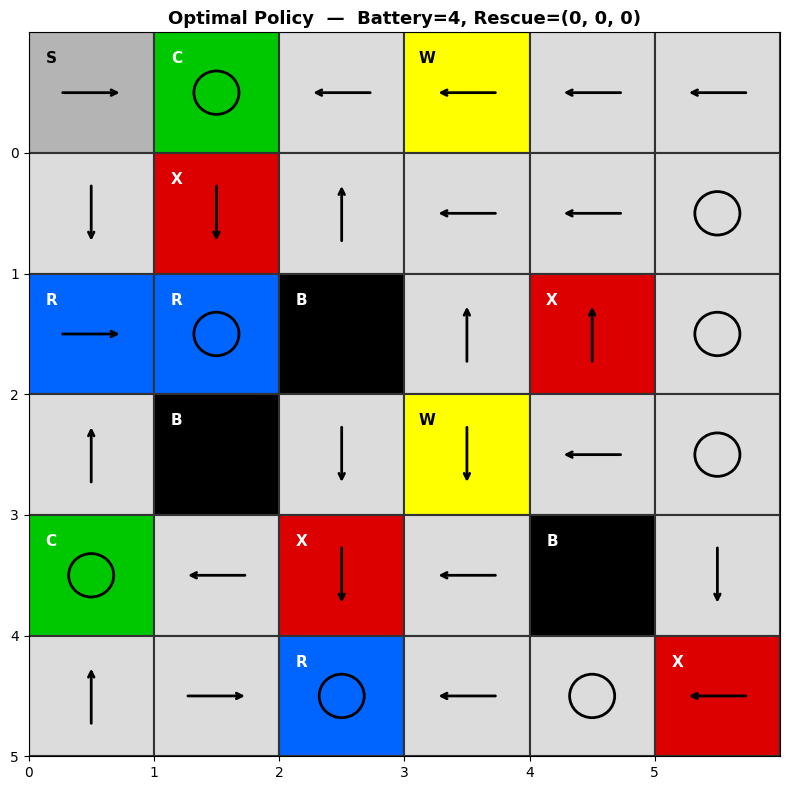

In [29]:
# Policy at start conditions
planner.render_policy_grid(battery_level=4, rescue_status=(0, 0, 0))

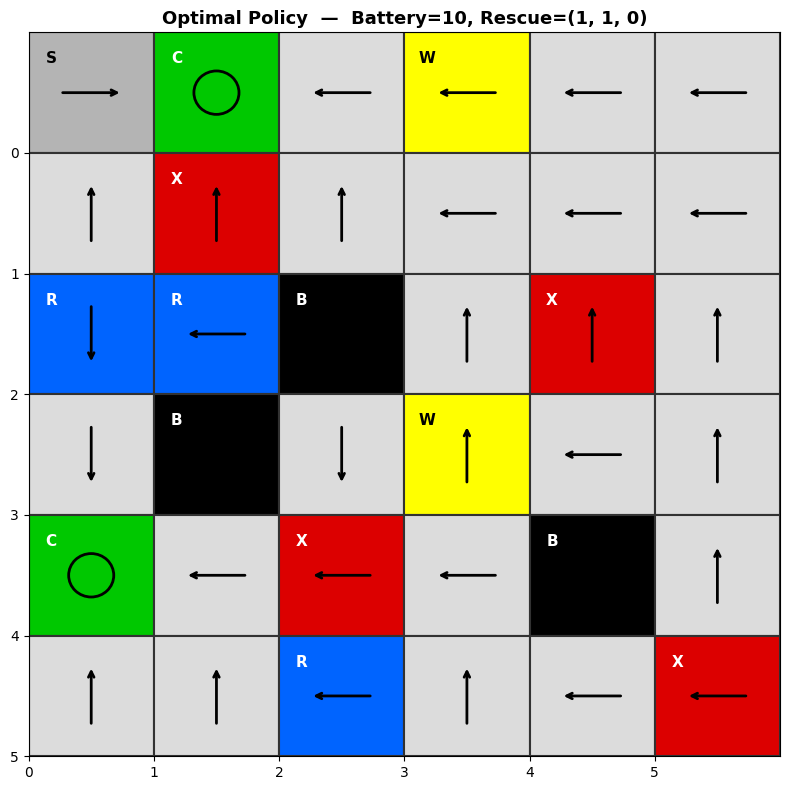

In [30]:
# Policy when two targets already rescued and battery is high
planner.render_policy_grid(battery_level=10, rescue_status=(1, 1, 0))

## Cell 9 — State Value Heatmaps

The heatmaps below show **V\*(s)** — the optimal value — across all grid positions for fixed battery and rescue status slices.

### Observed Patterns

**Heatmap 1 — Battery=4, Rescue=(0,0,0) (no targets rescued)**  
Rescue target cells (R) show the highest values since they yield a +20 reward. Cells adjacent to targets also carry elevated value due to discounted future reward propagation. Danger zones (X) show depressed values from the −10 penalty. Blocked cells appear as NaN (grey). The start cell (0,0) has moderate value — it is near a charging station but far from all targets.

**Heatmap 2 — Battery=10, Rescue=(0,0,0) (full battery, no rescues)**  
Values are uniformly higher than Heatmap 1 because the agent has more battery headroom to reach targets. The gradient towards rescue cells is steeper and charging stations contribute less marginal value since the agent rarely needs to detour for recharging.

**Heatmap 3 — Battery=10, Rescue=(1,1,0) (one target remaining)**  
Only the third rescue target (5,2) drives value. Cells in its neighbourhood show the highest V\*(s) and the gradient fans out from that single target. Regions far from (5,2) and lacking a direct path have lower value. Danger zones still create local depressions.

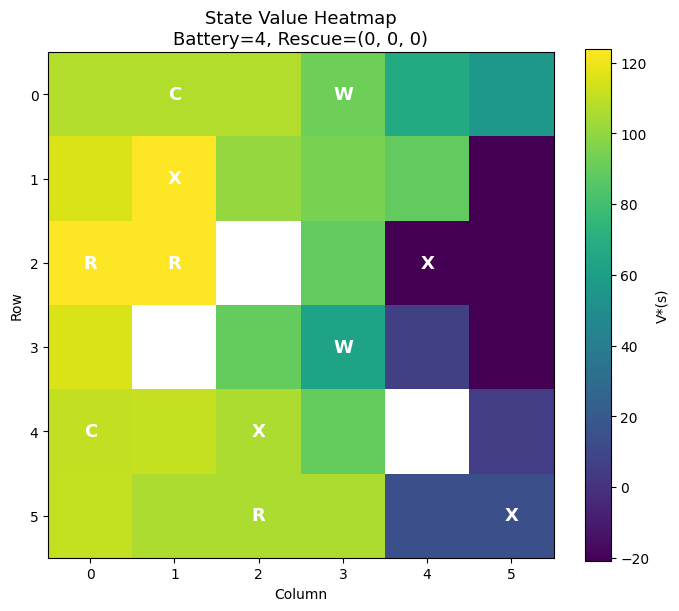

In [31]:
planner.plot_value_heatmap(battery_level=4,  rescue_status=(0, 0, 0))

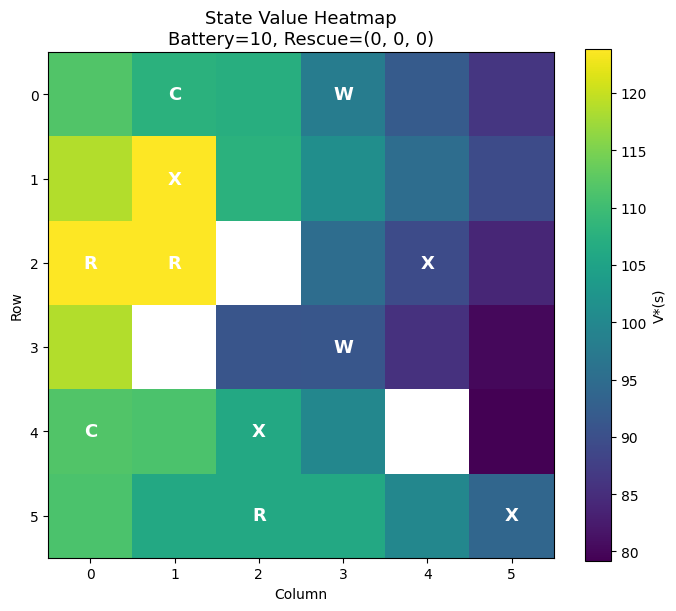

In [32]:
planner.plot_value_heatmap(battery_level=10, rescue_status=(0, 0, 0))

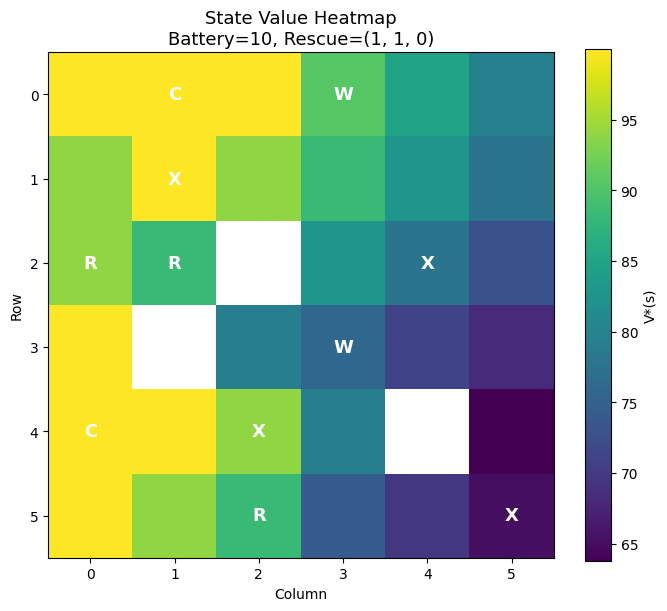

In [33]:
planner.plot_value_heatmap(battery_level=10, rescue_status=(1, 1, 0))

## Cell 10 — Optimal Policy Execution
Simulate the drone following the optimal policy extracted by Value Iteration.
Use the slider to step through each frame of the mission.

In [34]:
planner.simulate_optimal_rescue()


Executing Optimal Policy

  Pos=(0, 1)  Battery=10  Action=→  Reward=5  Total=5
  Pos=(1, 1)  Battery=9  Action=↓  Reward=-10  Total=-5
  Pos=(2, 1)  Battery=8  Action=↓  Reward=20  Total=15
  Pos=(2, 0)  Battery=7  Action=←  Reward=20  Total=35
  Pos=(3, 0)  Battery=6  Action=↓  Reward=-1  Total=34
  Pos=(4, 0)  Battery=10  Action=↓  Reward=5  Total=39
  Pos=(4, 0)  Battery=10  Action=↺  Reward=5  Total=44
  Pos=(4, 0)  Battery=10  Action=↺  Reward=5  Total=49
  Pos=(4, 0)  Battery=10  Action=↺  Reward=5  Total=54
  Pos=(4, 0)  Battery=10  Action=↺  Reward=5  Total=59
  Pos=(4, 0)  Battery=10  Action=↺  Reward=5  Total=64
  Pos=(4, 0)  Battery=10  Action=↺  Reward=5  Total=69
  Pos=(4, 0)  Battery=10  Action=↺  Reward=5  Total=74
  Pos=(4, 0)  Battery=10  Action=↺  Reward=5  Total=79
  Pos=(4, 0)  Battery=10  Action=↺  Reward=5  Total=84
  Pos=(4, 0)  Battery=10  Action=↺  Reward=5  Total=89
  Pos=(4, 0)  Battery=10  Action=↺  Reward=5  Total=94
  Pos=(4, 0)  Battery=10  Action=↺  Re

## Cell 11 — Explain: Curse of Dimensionality 
How state space changes if: 
● grid becomes 10×10,  
● more rescue targets are added,  
● weather conditions become dynamic.  
Is DP sufficient? Discuss: 
● why DP becomes difficult,.

- Larger Grid (10×10): Position states increase from 36 to 100, causing a proportional increase in total state space and more Value Iteration computations.

- More Rescue Targets: Each additional target adds a rescued/not-rescued state variable, causing the rescue-status space to grow exponentially (2
n), significantly increasing the number of states.

- Dynamic Weather: If weather is included as an observable state variable (e.g., Calm, Windy, Stormy), the state space is multiplied by the number of weather conditions. If weather only affects movement probabilities, it increases transition-model complexity rather than state-space size.

- Curse of Dimensionality: As more state variables are added, the total number of states grows rapidly, resulting in larger value tables, increased memory usage, more Bellman updates, and slower convergence of Value Iteration.

A example usecase :
Grid Size = 10×10 → 100 position states
Battery = 0–10 → 11 battery states
6 Rescue Targets → 2^6=64 rescue-status combinations
3 Weather Conditions (Calm, Windy, Stormy) → 3 weather states

Total State Space:
100 × 11 × 64 × 3 = 211,200 states

Current State Space = 6 × 6 × 11 × 2^3 = 3,168 states

Increase is about 67 times